### **Анализ динамики курса EUR/USD: визуализация ключевых экономических событий**

В данном проекте исследуется динамика обменного курса EUR/USD на основе исторических данных за длительный период [Daily Exchange Rates per Euro 1999-](https://www.kaggle.com/datasets/lsind18/euro-exchange-daily-rates-19992020). С помощью методов визуализации и анализа временных рядов рассматривается влияние ключевых мировых событий на валютный рынок, включая мировой финансовый кризис 2007-2008 годов, долговой кризис еврозоны, пандемию COVID-19 и геополитическую нестабильность, связанную с российско-украинской войной. Для выявления долгосрочных тенденций применяется скользящее среднее, а результаты представлены в виде наглядных графиков, отражающих изменение курса и его связь с экономическими и политическими событиями.

In [1]:
#Импортируем необходимые библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.style as style
import matplotlib.dates as mdates
%matplotlib inline

In [2]:
df = pd.read_csv('euro-daily-hist_1999_2026.csv')

Изучим набор данных:

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7082 entries, 0 to 7081
Data columns (total 41 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Period\Unit:              7082 non-null   object 
 1   [Australian dollar ]      7082 non-null   object 
 2   [Bulgarian lev ]          6573 non-null   object 
 3   [Brazilian real ]         6814 non-null   object 
 4   [Canadian dollar ]        7082 non-null   object 
 5   [Swiss franc ]            7082 non-null   object 
 6   [Chinese yuan renminbi ]  6814 non-null   object 
 7   [Cypriot pound ]          2346 non-null   object 
 8   [Czech koruna ]           7082 non-null   object 
 9   [Danish krone ]           7082 non-null   object 
 10  [Estonian kroon ]         3130 non-null   object 
 11  [UK pound sterling ]      7082 non-null   object 
 12  [Greek drachma ]          520 non-null    object 
 13  [Hong Kong dollar ]       7082 non-null   object 
 14  [Croatia

Первые 10 записей:

In [4]:
df.head(10)

,Period\Unit:,[Australian dollar ],[Bulgarian lev ],[Brazilian real ],[Canadian dollar ],[Swiss franc ],[Chinese yuan renminbi ],[Cypriot pound ],[Czech koruna ],[Danish krone ],...,[Romanian leu ],[Russian rouble ],[Swedish krona ],[Singapore dollar ],[Slovenian tolar ],[Slovak koruna ],[Thai baht ],[Turkish lira ],[US dollar ],[South African rand ]
0,2026-06-04,1.6297,NaN,5.8951,1.6176,0.9168,7.8848,NaN,24.218,7.4742,...,5.2581,NaN,10.8803,1.4929,NaN,NaN,37.949,53.5137,1.164,18.9027
1,2026-06-03,1.6218,NaN,5.8284,1.6094,0.9167,7.862,NaN,24.189,7.4739,...,5.2576,NaN,10.884,1.489,NaN,NaN,38.007,53.3749,1.1614,18.8963
2,2026-06-02,1.6221,NaN,5.831,1.6119,0.9149,7.8778,NaN,24.243,7.474,...,5.2553,NaN,10.825,1.4892,NaN,NaN,37.958,53.5000,1.1649,18.8756
3,2026-06-01,1.6234,NaN,5.8515,1.6106,0.9128,7.8786,NaN,24.285,7.4737,...,5.2531,NaN,10.789,1.4881,NaN,NaN,37.914,53.4483,1.1646,18.9289
4,2026-05-29,1.6238,NaN,5.8747,1.6074,0.9111,7.8793,NaN,24.282,7.4731,...,5.2523,NaN,10.772,1.487,NaN,NaN,37.866,53.4297,1.1644,18.8913
5,2026-05-28,1.6318,NaN,5.8928,1.6094,0.9167,7.8762,NaN,24.293,7.4729,...,5.2481,NaN,10.8215,1.4865,NaN,NaN,37.988,53.3213,1.1617,18.9939
6,2026-05-27,1.6321,NaN,5.8718,1.6099,0.9153,7.8923,NaN,24.284,7.4726,...,5.2379,NaN,10.7895,1.4869,NaN,NaN,37.96,53.4194,1.1637,19.0375
7,2026-05-26,1.6236,NaN,5.8404,1.6069,0.9136,7.8939,NaN,24.257,7.4721,...,5.2385,NaN,10.8245,1.4866,NaN,NaN,37.997,53.4070,1.1634,19.03
8,2026-05-25,1.624,NaN,5.8245,1.6082,0.9099,7.899,NaN,24.259,7.4719,...,5.2451,NaN,10.7965,1.4873,NaN,NaN,37.816,53.2250,1.1643,19.0121
9,2026-05-22,1.6283,NaN,5.8165,1.6002,0.9119,7.8791,NaN,24.289,7.4731,...,5.2490,NaN,10.8695,1.4846,NaN,NaN,37.875,53.0067,1.1595,19.1045


Первое, что бросается в глаза, - это названия столбцов. Приведём их к стилю snake_case для удобства дальнейшей работы:

In [5]:
def clean_col(column_name):
    column_name = column_name.replace('[', '') #Убираем квадратные скобки из названий столбцов
    column_name = column_name.replace(']', '')
    column_name = column_name.strip() #Убираем все пробелы в начале и конце названий
    column_name = column_name.replace(' ', '_') #Заменяем пробел между словами на _
    return column_name
 
new_column_names = [] #Создаём новый список, который будет содержать обработанные названия столбцов
for column in df.columns: 
    col_name = clean_col(column)
    new_column_names.append(col_name)

df.columns = new_column_names #Заменяем исходные названия столбцов на обработанные
df.rename({'Period\\Unit:' : 'Time'}, axis = 1, inplace = True) #Отдельно меняем название для столбца 'Period\Unit:' на 'Time'
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7082 entries, 0 to 7081
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Time                   7082 non-null   object 
 1   Australian_dollar      7082 non-null   object 
 2   Bulgarian_lev          6573 non-null   object 
 3   Brazilian_real         6814 non-null   object 
 4   Canadian_dollar        7082 non-null   object 
 5   Swiss_franc            7082 non-null   object 
 6   Chinese_yuan_renminbi  6814 non-null   object 
 7   Cypriot_pound          2346 non-null   object 
 8   Czech_koruna           7082 non-null   object 
 9   Danish_krone           7082 non-null   object 
 10  Estonian_kroon         3130 non-null   object 
 11  UK_pound_sterling      7082 non-null   object 
 12  Greek_drachma          520 non-null    object 
 13  Hong_Kong_dollar       7082 non-null   object 
 14  Croatian_kuna          5941 non-null   object 
 15  Hung

Изменим тип данных столбца `Time` на datetime и отсортируем данные по времени:

In [6]:
df['Time'] = pd.to_datetime(df['Time'])
df.sort_values('Time', inplace = True) #Сортируем значения по дате в порядке возрастания 
df.reset_index(drop = True, inplace = True) #После сортировки сбрасываем текущие значения индекса
                                            #и создаем новые, которые идут подряд с 0

На этом этапе предварительная очистка данных завершена.

---

Поскольку целью дальнейшего анализа является курс доллара, все последующие операции будут выполняться со столбцом `US_dollar`:

In [7]:
euro_to_dollar = df[['Time','US_dollar']]

Изучим значения столбца `US_dollar`, чтобы выявить возможные ошибки в записях и выбросы:

In [8]:
euro_to_dollar['US_dollar'].value_counts()

-         62
1.2276     9
1.0867     8
1.0888     8
1.1215     8
          ..
1.5660     1
1.5632     1
1.5722     1
1.5693     1
1.1595     1
Name: US_dollar, Length: 3927, dtype: int64

Как видно из результатов, 62 строки содержат значение `-`. Удалим их и приведём столбец `US_dollar` к типу float:

In [9]:
euro_to_dollar = euro_to_dollar[euro_to_dollar['US_dollar'] != '-']
euro_to_dollar['US_dollar'] = euro_to_dollar['US_dollar'].astype(float)
euro_to_dollar.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7020 entries, 0 to 7081
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Time       7020 non-null   datetime64[ns]
 1   US_dollar  7020 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 164.5 KB


Построим линейный график, чтобы визуализировать динамику обменного курса евро к доллару:

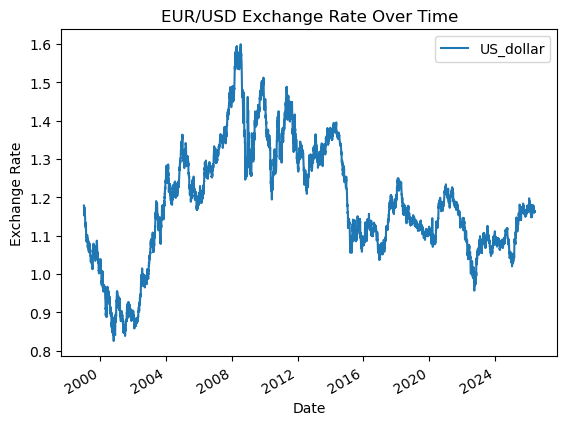

In [10]:
euro_to_dollar.plot.line(x = 'Time', y = 'US_dollar')
plt.title('EUR/USD Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.show()

Если посмотреть на форму линии, можно заметить множество небольших изгибов вместо плавной кривой. Эти колебания не являются случайными - они отражают ежедневные изменения обменного курса. Изо дня в день курс то повышается, то понижается. При этом устойчивые тенденции роста или снижения проявляются только в долгосрочной перспективе - в течение месяцев или даже лет.

Чтобы сгладить краткосрочные колебания и сделать линию более наглядной, можно использовать скользящее среднее за месяц:

In [11]:
euro_to_dollar['rolling_mean'] = euro_to_dollar['US_dollar'].rolling(30).mean()
euro_to_dollar[26:31]

,Time,US_dollar,rolling_mean
26,1999-02-09,1.1333,NaN
27,1999-02-10,1.1342,NaN
28,1999-02-11,1.1312,NaN
29,1999-02-12,1.1244,1.150667
30,1999-02-15,1.1238,1.148830


Как видно, значения в столбце `rolling_mean` с индекса 0 по 28 содержат `NaN` из-за недостаточного количества данных для расчёта скользящего среднего. В связи с этим для дальнейшей визуализации будут использованы данные, начиная с индекса 29:

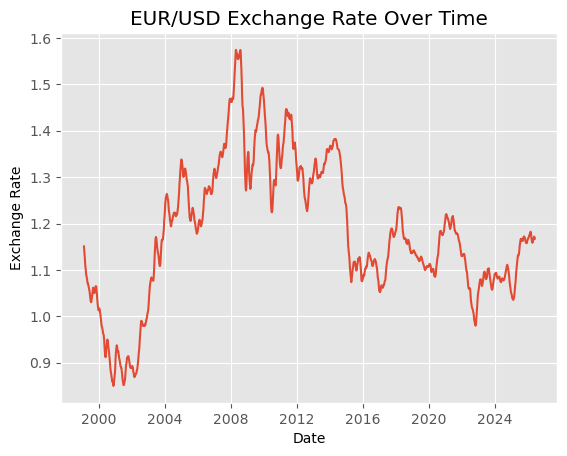

In [12]:
style.use('ggplot')
plt.plot(euro_to_dollar.loc[29:, 'Time'], euro_to_dollar.loc[29:, 'rolling_mean'])
plt.title('EUR/USD Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.show()

style.use('default')

На графике видно, что максимальное значение курса EUR/USD наблюдалось в 2008 году (`≈1,60`), после чего последовало резкое снижение до `≈1,23`. Такая динамика связана с началом мирового финансового кризиса: первоначально евро укрепился на фоне ослабления доллара США, однако по мере углубления кризиса инвесторы стали активнее переходить в доллар как защитный актив, что привело к снижению курса евро.

Следующий заметный период приходится на долговой кризис еврозоны (2010-2015 гг.). В этот период курс EUR/USD демонстрировал устойчивое снижение и приблизился к паритету (`≈1,06`). Давление на евро усилилось из-за долговых проблем ряда стран еврозоны, что потребовало вмешательства Европейского центрального банка, включая программы количественного смягчения, направленные на стабилизацию экономики.

Начиная с 2016 года курс EUR/USD в основном находился в диапазоне `1,05-1,20`. Референдум о выходе Великобритании из Европейского союза (Brexit) усилил неопределённость на европейских финансовых рынках и вызвал краткосрочные колебания курса. В начале 2020 года пандемия COVID-19 привела к росту спроса на доллар как защитный актив, однако последующие масштабные меры денежно-кредитного стимулирования со стороны ФРС США и ЕЦБ способствовали восстановлению курса евро.

---

Следующий шаг - выстроить интерпретацию динамики курса EUR/USD через разделение временного ряда на три периода: 2016-2019 гг. (относительно стабильный докризисный период), 2020-2021 гг. (период пандемийного шока) и с 2022 г. по настоящее время (период повышенной геополитической нестабильности, связанный с войной между Россией и Украиной):

In [13]:
euro_to_dollar['year'] = euro_to_dollar['Time'].dt.year
EUR_to_USD_2016_2019 = euro_to_dollar[euro_to_dollar['year'].between(2016, 2019)]
EUR_to_USD_2020_2021 = euro_to_dollar[euro_to_dollar['year'].between(2020, 2021)]
EUR_to_USD_since_2022 = euro_to_dollar[euro_to_dollar['year'] >= 2022]

Построим табличную диаграмму:

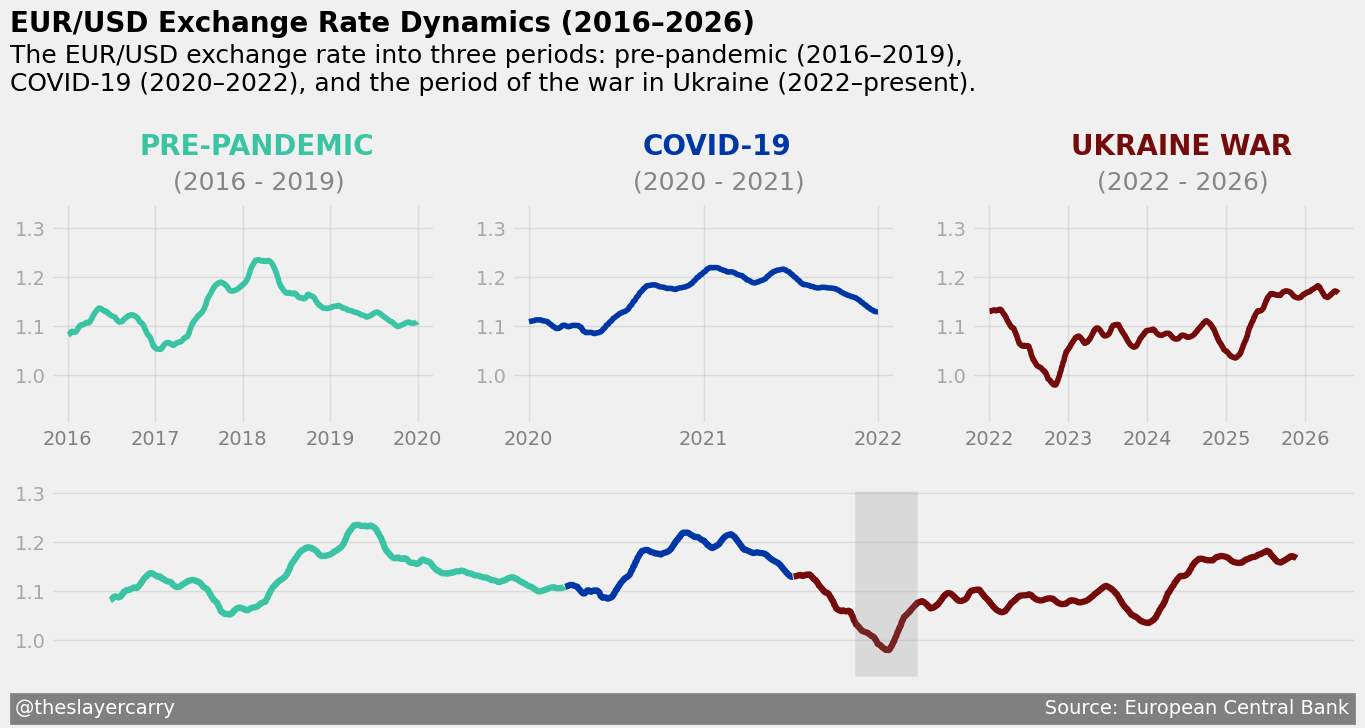

In [14]:
# Для данной визуализации мы будем использовать стиль `fivethirtyeight`
style.use('fivethirtyeight')
plt.figure(figsize = (15, 6), dpi = 100)

# Верхний ряд: три отдельных периода
ax1 = plt.subplot(2, 3, 1)  # 2016-2019
ax2 = plt.subplot(2, 3, 2)  # 2020-2021
ax3 = plt.subplot(2, 3, 3)  # 2022-настоящее время

# Нижний ряд: общий график на всю ширину
ax4 = plt.subplot(2, 1, 2)
axes = [ax1, ax2, ax3, ax4]

### Строим графики:
ax1.plot(EUR_to_USD_2016_2019['Time'], EUR_to_USD_2016_2019['rolling_mean'], color = '#3bc4a4')
ax2.plot(EUR_to_USD_2020_2021['Time'], EUR_to_USD_2020_2021['rolling_mean'], color = '#0037a4')
ax3.plot(EUR_to_USD_since_2022['Time'], EUR_to_USD_since_2022['rolling_mean'], color = '#740c0c')

ax4.plot(EUR_to_USD_2016_2019['Time'], EUR_to_USD_2016_2019['rolling_mean'], color = '#3bc4a4', linewidth = 4.5)
ax4.plot(EUR_to_USD_2020_2021['Time'], EUR_to_USD_2020_2021['rolling_mean'], color = '#0037a4', linewidth = 4.5)
ax4.plot(EUR_to_USD_since_2022['Time'], EUR_to_USD_since_2022['rolling_mean'], color = '#740c0c', linewidth = 4.5)


# Для каждого графика убираем лишние структурные элементы для максимизации отношения данных к чернилам
for ax in axes:
    ax.set_ylim(0.9, 1.35)
    ax.set_yticks([1.0, 1.1, 1.2, 1.3])
    ax.set_yticklabels(['1.0', '1.1','1.2', '1.3'], alpha=0.3)
    ax.grid(alpha=0.57)
    ax.xaxis.set_major_locator(mdates.YearLocator()) #Показываем только год
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', colors = 'grey')

# Для нижнего общего графика отдельно убираем метки на оси x и выделяем минимальное значения курса EUR-USD
ax4.set_xticks([])
ax4.axvline(x = 19290, ymin = 0.06, ymax = 0.9, color = 'grey', linewidth = 45, alpha = 0.2)

### Добавляем заголовок и описание
ax1.text(16560, 1.70, 'EUR/USD Exchange Rate Dynamics (2016–2026)',
         fontsize=20, weight='bold')
ax1.text(16560, 1.58, '''The EUR/USD exchange rate into three periods: pre-pandemic (2016–2019), 
COVID-19 (2020–2022), and the period of the war in Ukraine (2022–present).''',
         fontsize=18)

#Подписываем каждый график
ax1.text(17100, 1.45, 'PRE-PANDEMIC', color = '#3bc4a4', size = 20, weight = 'bold')
ax1.text(17240, 1.38, '(2016 - 2019)', size = 18, alpha = 0.95, color = 'grey')

ax2.text(18500, 1.45, 'COVID-19', color = '#0037a4', size = 20, weight = 'bold')
ax2.text(18480, 1.38, '(2020 - 2021)', size = 18, alpha = 0.95, color = 'grey')

ax3.text(19370, 1.45, 'UKRAINE WAR', color = '#740c0c', size = 20, weight = 'bold')
ax3.text(19490, 1.38, '(2022 - 2026)', size = 18, alpha = 0.95, color = 'grey')

ax4.text(16500, 0.85, s = '@theslayercarry' + ' '*142 + 'Source: European Central Bank', backgroundcolor = 'grey', color = 'white')
plt.show()